In [33]:
import joblib

import umap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight

from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths

paths = load_project_paths()

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 5 seconds chunks

In [77]:
dataset = load_memmap_dataset(run_name="run_mil", reduced=True, soundscape=False)

le_class_name = joblib.load(paths.label_encoders_dir / "class_name.joblib")
le_primary_label = joblib.load(paths.label_encoders_dir / "primary_label.joblib")

In [85]:
y_class_name = le_class_name.inverse_transform(dataset.y[:, 0])
y_primary_label = le_primary_label.inverse_transform(dataset.y[:, 1])

In [129]:
weights = np.maximum(0.001, np.log(compute_sample_weight("balanced", dataset.y[:, 1])))

idx = resample(np.arange(dataset.X.shape[0]), stratify=None, replace=True, sample_weight=weights, n_samples=5000, random_state=42)
idx = np.unique(idx)
print(len(idx))

4935


In [130]:
np.unique(y_class_name[idx], return_counts=True)

(array(['Amphibia', 'Aves', 'Insecta', 'Mammalia'], dtype=object),
 array([ 938, 3752,   49,  196]))

In [118]:
model = umap.UMAP(n_neighbors=50, random_state=42)
embeddings = model.fit_transform(dataset.X[idx])

/Users/bsh2022/Study/master_ue/ml/birdclef_2026_ML/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


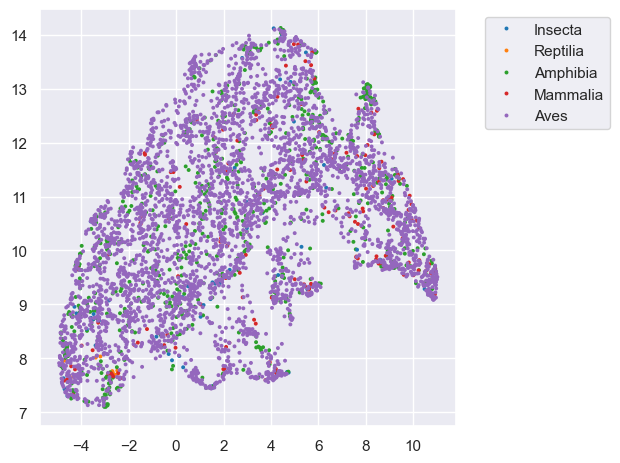

In [119]:
sns.scatterplot(
    x=embeddings[:, 0],
    y=embeddings[:, 1],
    hue=y_class_name[idx],
    palette="tab10",
    s=8,
    edgecolor="none",
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_44162/1011672093.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


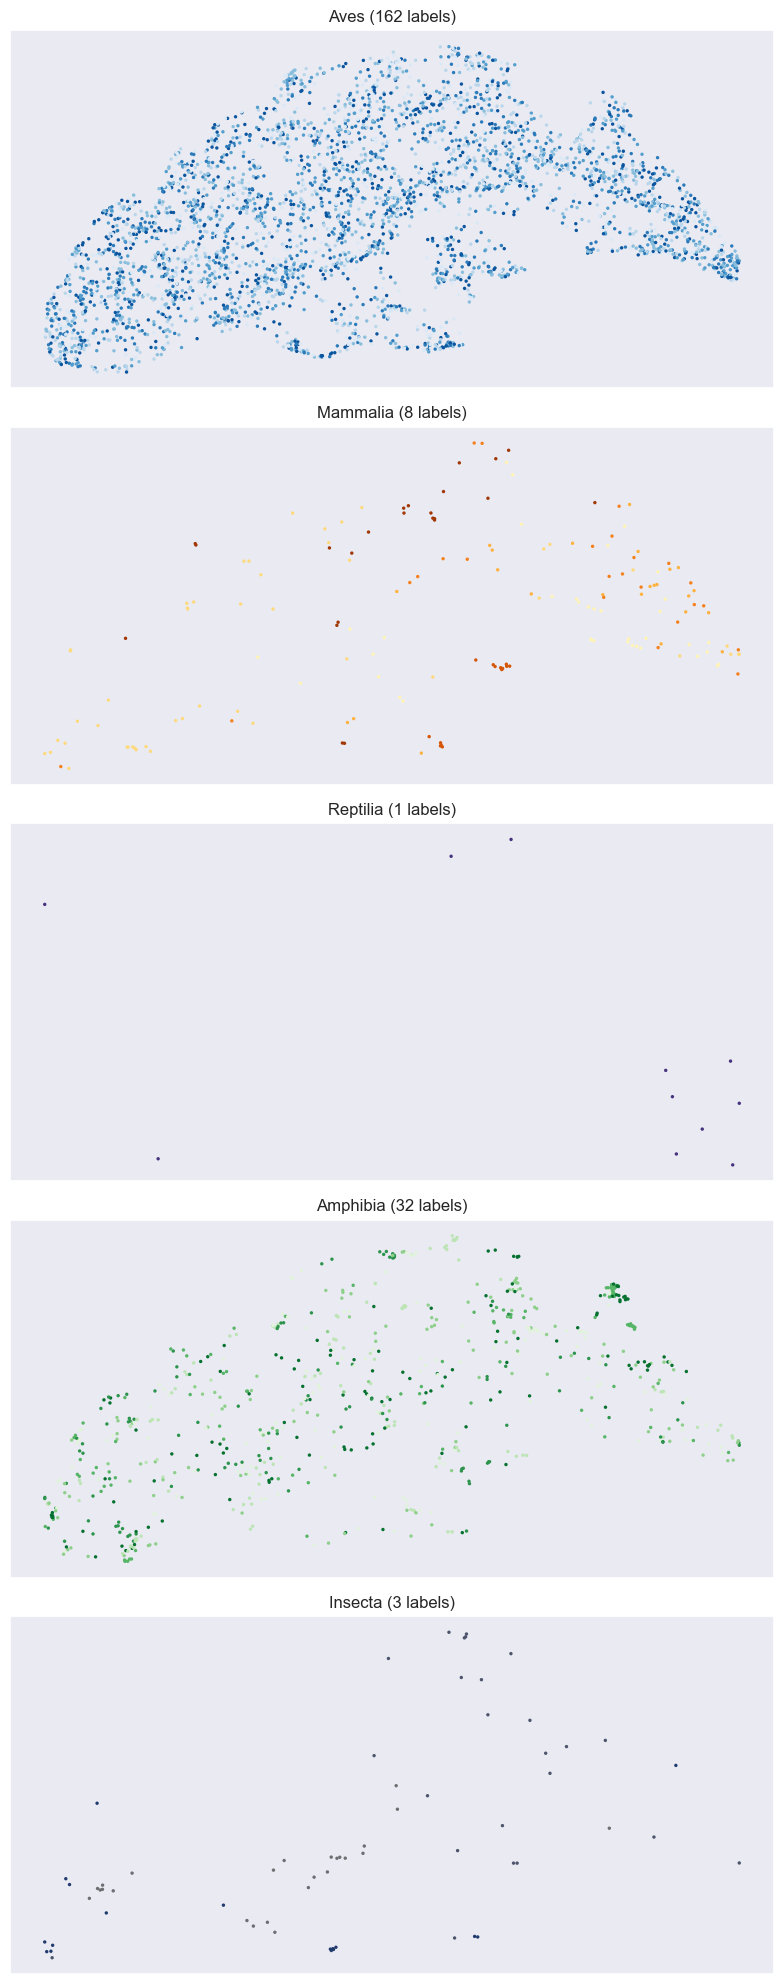

In [120]:
class_names = ["Aves", "Mammalia", "Reptilia", "Amphibia", "Insecta"]

# choose visually distinct, semantically reasonable palettes
palette_map = {
    "Aves": sns.color_palette("Blues", as_cmap=False),
    "Mammalia": sns.color_palette("YlOrBr", as_cmap=False),
    "Reptilia": sns.color_palette("viridis", as_cmap=False),
    "Amphibia": sns.color_palette("Greens", as_cmap=False),
    "Insecta": sns.color_palette("cividis", as_cmap=False),
}

fig, axes = plt.subplots(5, 1, figsize=(8, 20), constrained_layout=True)

for ax, cls in zip(axes, class_names):
    mask = (y_class_name[idx] == cls)

    emb = embeddings[mask]
    labels = y_primary_label[idx][mask]

    unique_labels = np.unique(labels)
    n = len(unique_labels)

    # resample palette to number of sublabels
    base_palette = palette_map[cls]
    colors = sns.color_palette(base_palette.as_hex() if hasattr(base_palette, "as_hex") else base_palette, n_colors=n)

    lut = dict(zip(unique_labels, colors))
    point_colors = [lut[l] for l in labels]

    ax.scatter(
        emb[:, 0],
        emb[:, 1],
        c=point_colors,
        s=6,
        edgecolors="none",
        #alpha=0.8
    )

    ax.set_title(f"{cls} ({n} labels)")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

In [92]:
(y_class_name[idx] == "Amphibia").sum()

np.int64(1704)

In [90]:
y_primary_label[idx]

array(['1161364', '1161364', '1161364', ..., 'yecmac', 'yecpar',
       'yeofly1'], shape=(3742,), dtype=object)